### Initial Imports and Data Splits

In [1]:
# import statements --> SOME OF THESE MAY NOT BE NEEDED
%matplotlib inline 
import numpy as np 

from matplotlib import pyplot as plt 
from matplotlib.cm import get_cmap
#from matplotlib.ticker import MaxNLocator
#import matplotlib.gridspec as gridspec
#import matplotlib.colors as mcolors
#import colorcet as cc
#from matplotlib.patches import Rectangle, FancyArrowPatch
#import matplotlib.ticker as ticker
#from mpl_toolkits.mplot3d import Axes3D
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#import mpl_scatter_density
#from astropy.visualization import LogStretch
#from astropy.visualization.mpl_normalize import ImageNormalize

#import h5py

#from astropy.io import fits,ascii,votable
#from astropy import units as u 
#from astropy import constants as const
#from astropy import table
#from astropy.cosmology import Planck15,FlatLambdaCDM
#from astropy.table import Table

#from sklearn.cluster import KMeans
#from sklearn import mixture
#from itertools import combinations
#from sklearn.neighbors import KNeighborsRegressor
#from sklearn.utils import check_array
#from sklearn.neighbors._base import _get_weights
#imports for TWO-NN
#import scipy
from sklearn import neighbors
from sklearn.preprocessing import StandardScaler
#from sklearn import preprocessing

#import scipy.integrate
#from scipy.integrate import quad
#import numba
#from sklearn.datasets import load_digits
import umap
#import umap.plot
from umap.umap_ import nearest_neighbors
import pandas as pd
#import plotly
import plotly.express as px

#imports for plotly graphing
#import plotly.graph_objects as go
#from plotly.subplots import make_subplots

import pickle

pd.set_option('display.max_columns', None)

#BRETT NOTEBOOK IMPORTS
from pathlib import Path

from importlib import reload
import utils
reload(utils)
from minisom import MiniSom

# imports from animation_simplified2 notebook
import seaborn as sns
sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})
import os
import copy

/Users/finianashmead/miniconda3/envs/newmac1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import umapz2

In [3]:
data = pd.read_parquet('COSMOS2020_processed_260724.parquet')
spec95 = pd.read_parquet('speczCL95_processed_260724.parquet')

In [4]:
data

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H
7,12,150.476809,2.331511,0,0.432424,0.006043,0.017385,0.367684,0.004799,0.013929,0.539085,0.006673,0.012705,0.913139,0.006940,0.008187,0.995689,0.010382,0.011179,1.010389,0.021430,0.021652,1.176385,0.018240,0.016771,1.238664,0.023098,0.021265,1.273614,0.031158,0.026693,0.793401,0.012663,0.021113,0.623383,0.011264,0.024039,0.7070,0,NaN,30,0.00,5,9.048000e+08,0.1,1,-17.59872,-18.85507,-18.93651,8.69380,8.65194,8.74706,8.64422,-0.18369,-8.815,24.810225,24.986313,24.570856,23.998658,23.904690,23.888779,23.723626,23.667616,23.637405,24.151268,24.413112,-0.176089,0.415457,0.572198,0.093968,0.015911,0.165153,0.056011
39,73,149.468025,1.625609,0,1.057806,0.006321,0.007477,1.301316,0.007003,0.005769,2.870638,0.011023,0.003954,3.669017,0.012785,0.003763,4.321371,0.018494,0.004597,5.147967,0.045866,0.009110,5.366495,0.022263,0.004492,5.903986,0.031370,0.006063,6.666023,0.046399,0.007598,4.142945,0.036884,0.011779,4.426406,0.054762,0.016462,0.4290,0,NaN,30,0.34,9,1.609000e+09,0.2,1,-17.40718,-19.16920,-19.50800,9.06086,9.01925,9.10800,9.01447,0.08064,-8.977,23.838985,23.614043,22.755054,22.488626,22.310946,22.120911,22.075773,21.972137,21.840333,22.356727,22.284872,0.224942,0.858989,0.266428,0.177680,0.190035,0.045137,0.103637
40,74,150.488035,1.875422,0,0.941051,0.003713,0.004937,1.032136,0.004159,0.004320,1.066959,0.005443,0.005254,1.123350,0.005748,0.005525,1.208387,0.008979,0.007981,1.734654,0.019518,0.011504,2.413042,0.014805,0.006643,2.547439,0.017875,0.008007,2.257407,0.024673,0.011931,2.951406,0.013003,0.005829,3.054308,0.014661,0.006387,1.5087,0,NaN,29,2.23,10,9.048000e+08,0.1,1,-20.37010,-21.24365,-21.42674,9.49598,9.44923,9.54398,9.50023,0.99993,-8.536,23.965967,23.865658,23.829631,23.773713,23.694485,23.301968,22.943588,22.884741,23.015975,22.724928,22.687718,0.100310,0.036027,0.055918,0.079228,0.392517,0.358380,0.058847
46,85,150.476436,2.334178,0,0.685237,0.005227,0.009492,0.669388,0.004202,0.006701,0.744438,0.005884,0.008114,1.119968,0.005803,0.005582,1.484551,0.008772,0.006335,1.619744,0.018884,0.011903,1.782537,0.015855,0.009621,1.867551,0.020190,0.012329,2.274360,0.027033,0.012969,2.573668,0.012908,0.006634,1.992754,0.011691,0.007805,1.0800,0,NaN,29,2.19,5,2.273000e+08,0.2,0,-19.16843,-20.47925,-20.51206,9.14079,9.10236,9.18581,9.12799,0.90000,-8.234,24.310399,24.335805,24.220428,23.776986,23.471012,23.376384,23.272404,23.221819,23.007852,22.873619,23.151366,-0.025406,0.115376,0.443442,0.305974,0.094628,0.103980,0.050585
57,104,149.475722,1.626313,0,0.389645,0.004690,0.015066,0.377765,0.005186,0.014719,0.468260,0.008271,0.018192,0.582758,0.009130,0.016919,1.032440,0.013830,0.014389,1.231677,0.034203,0.028396,1.327044,0.017144,0.013989,1.671119,0.023782,0.016241,1.823997,0.035115,0.021015,2.302721,0.033234,0.019095,2.590386,0.044562,0.022890,1.2817,0,NaN,29,1.01,7,5.709000e+08,0.2,0,-18.94804,-20.47051,-20.73870,9.42859,9.36886,9.49659,9.40345,0.76785,-8.597,24.923327,24.956946,24.723783,24.486279,23.865338,23.673758,23.592787,23.342482,23.247440,22.994396,22.866589,-0.033620,0.233163,0.237504,0.620941,0.191580,0.080971,0.250305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [5]:
scaled_data = data.copy()
# Initialize scaler
scaler = StandardScaler()
cols_to_scale = ['u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-J', 'J-H']
# Fit and transform selected columns
scaled_data[cols_to_scale] = scaler.fit_transform(scaled_data[cols_to_scale])

In [6]:
UMAP_dense = umap.UMAP(n_neighbors=80, min_dist=0.0, metric='manhattan', n_components=3, random_state=41, densmap=True).fit(data[['u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-J', 'J-H']])


/Users/finianashmead/miniconda3/envs/newmac1/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [7]:
scaled_dense = umap.UMAP(n_neighbors=80, min_dist=0.0, metric='manhattan', n_components=3, random_state=41, densmap=True).fit(scaled_data[['u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-J', 'J-H']])


/Users/finianashmead/miniconda3/envs/newmac1/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [8]:
sumap = umap.UMAP(n_neighbors=80, min_dist=0.0, metric='manhattan', n_components=3, random_state=41, densmap=False).fit(scaled_data[['u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-J', 'J-H']])

/Users/finianashmead/miniconda3/envs/newmac1/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [9]:
UMAP_80_41 = umap.UMAP(n_neighbors=80, min_dist=0.0, metric='manhattan', n_components=3, random_state=41, densmap=False).fit(data[['u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-J', 'J-H']])


/Users/finianashmead/miniconda3/envs/newmac1/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [17]:
scaled_data['sUMAPnn80-1'] = sumap.embedding_[:,0].copy()
scaled_data['sUMAPnn80-2'] = sumap.embedding_[:,1].copy()
scaled_data['sUMAPnn80-3'] = sumap.embedding_[:,2].copy()

In [18]:
scaled_data['scaleddens80-1'] = scaled_dense.embedding_[:,0].copy()
scaled_data['scaleddens80-2'] = scaled_dense.embedding_[:,1].copy()
scaled_data['scaleddens80-3'] = scaled_dense.embedding_[:,2].copy()

In [19]:
data['dens80-1'] = UMAP_dense.embedding_[:,0].copy()
data['dens80-2'] = UMAP_dense.embedding_[:,1].copy()
data['dens80-3'] = UMAP_dense.embedding_[:,2].copy()

In [20]:
data['UMAPnn80-1'] = UMAP_80_41.embedding_[:,0].copy()
data['UMAPnn80-2'] = UMAP_80_41.embedding_[:,1].copy()
data['UMAPnn80-3'] = UMAP_80_41.embedding_[:,2].copy()

In [22]:
splits = umapz2.data_split(photcat=data, speccat=spec95, valid_size=len(spec95), rs=41)

In [23]:
scaled_splits = umapz2.data_split(photcat=scaled_data, speccat=spec95, valid_size=len(spec95), rs=41)

In [24]:
ks = [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
sets_d = {k: [0] for k in ks}
results_d = {k: [0] for k in ks}
sets_sd = {k: [0] for k in ks}
results_sd = {k: [0] for k in ks}
sets = {k: [0] for k in ks}
results = {k: [0] for k in ks}
sets_s = {k: [0] for k in ks}
results_s = {k: [0] for k in ks}

outliers_mean_d = []
outliers_std_d = []
nmads_mean_d = []
nmads_std_d = []
biases_mean_d = []
biases_std_d = []
outliers_mean_sd = []
outliers_std_sd = []
nmads_mean_sd = []
nmads_std_sd = []
biases_mean_sd = []
biases_std_sd = []
outliers_mean = []
outliers_std = []
nmads_mean = []
nmads_std = []
biases_mean = []
biases_std = []
outliers_mean_s = []
outliers_std_s = []
nmads_mean_s = []
nmads_std_s = []
biases_mean_s = []
biases_std_s = []

for k in ks:
    results_d[k], sets_d[k] = umapz2.crossvalidate_global(folds=5, data=splits['valid'], nn=k, map='dens80', tv='lp_photoz')
    results_sd[k], sets_sd[k] = umapz2.crossvalidate_global(folds=5, data=scaled_splits['valid'], nn=k, map='scaleddens80', tv='lp_photoz')
    results[k], sets[k] = umapz2.crossvalidate_global(folds=5, data=splits['valid'], nn=k, map='UMAPnn80', tv='lp_photoz')
    results_s[k], sets_s[k] = umapz2.crossvalidate_global(folds=5, data=scaled_splits['valid'], nn=k, map='sUMAPnn80', tv='lp_photoz')
    
    outliers_mean_d.append(results_d[k]['outliers_mean'])
    outliers_std_d.append(results_d[k]['outliers_range'])
    nmads_mean_d.append(results_d[k]['nmads_mean'])
    nmads_std_d.append(results_d[k]['nmads_range'])
    biases_mean_d.append(results_d[k]['biases_mean'])
    biases_std_d.append(results_d[k]['biases_range'])

    outliers_mean_sd.append(results_sd[k]['outliers_mean'])
    outliers_std_sd.append(results_sd[k]['outliers_range'])
    nmads_mean_sd.append(results_sd[k]['nmads_mean'])
    nmads_std_sd.append(results_sd[k]['nmads_range'])
    biases_mean_sd.append(results_sd[k]['biases_mean'])
    biases_std_sd.append(results_sd[k]['biases_range'])

    outliers_mean.append(results[k]['outliers_mean'])
    outliers_std.append(results[k]['outliers_range'])
    nmads_mean.append(results[k]['nmads_mean'])
    nmads_std.append(results[k]['nmads_range'])
    biases_mean.append(results[k]['biases_mean'])
    biases_std.append(results[k]['biases_range'])

    outliers_mean_s.append(results_s[k]['outliers_mean'])
    outliers_std_s.append(results_s[k]['outliers_range'])
    nmads_mean_s.append(results_s[k]['nmads_mean'])
    nmads_std_s.append(results_s[k]['nmads_range'])
    biases_mean_s.append(results_s[k]['biases_mean'])
    biases_std_s.append(results_s[k]['biases_range'])

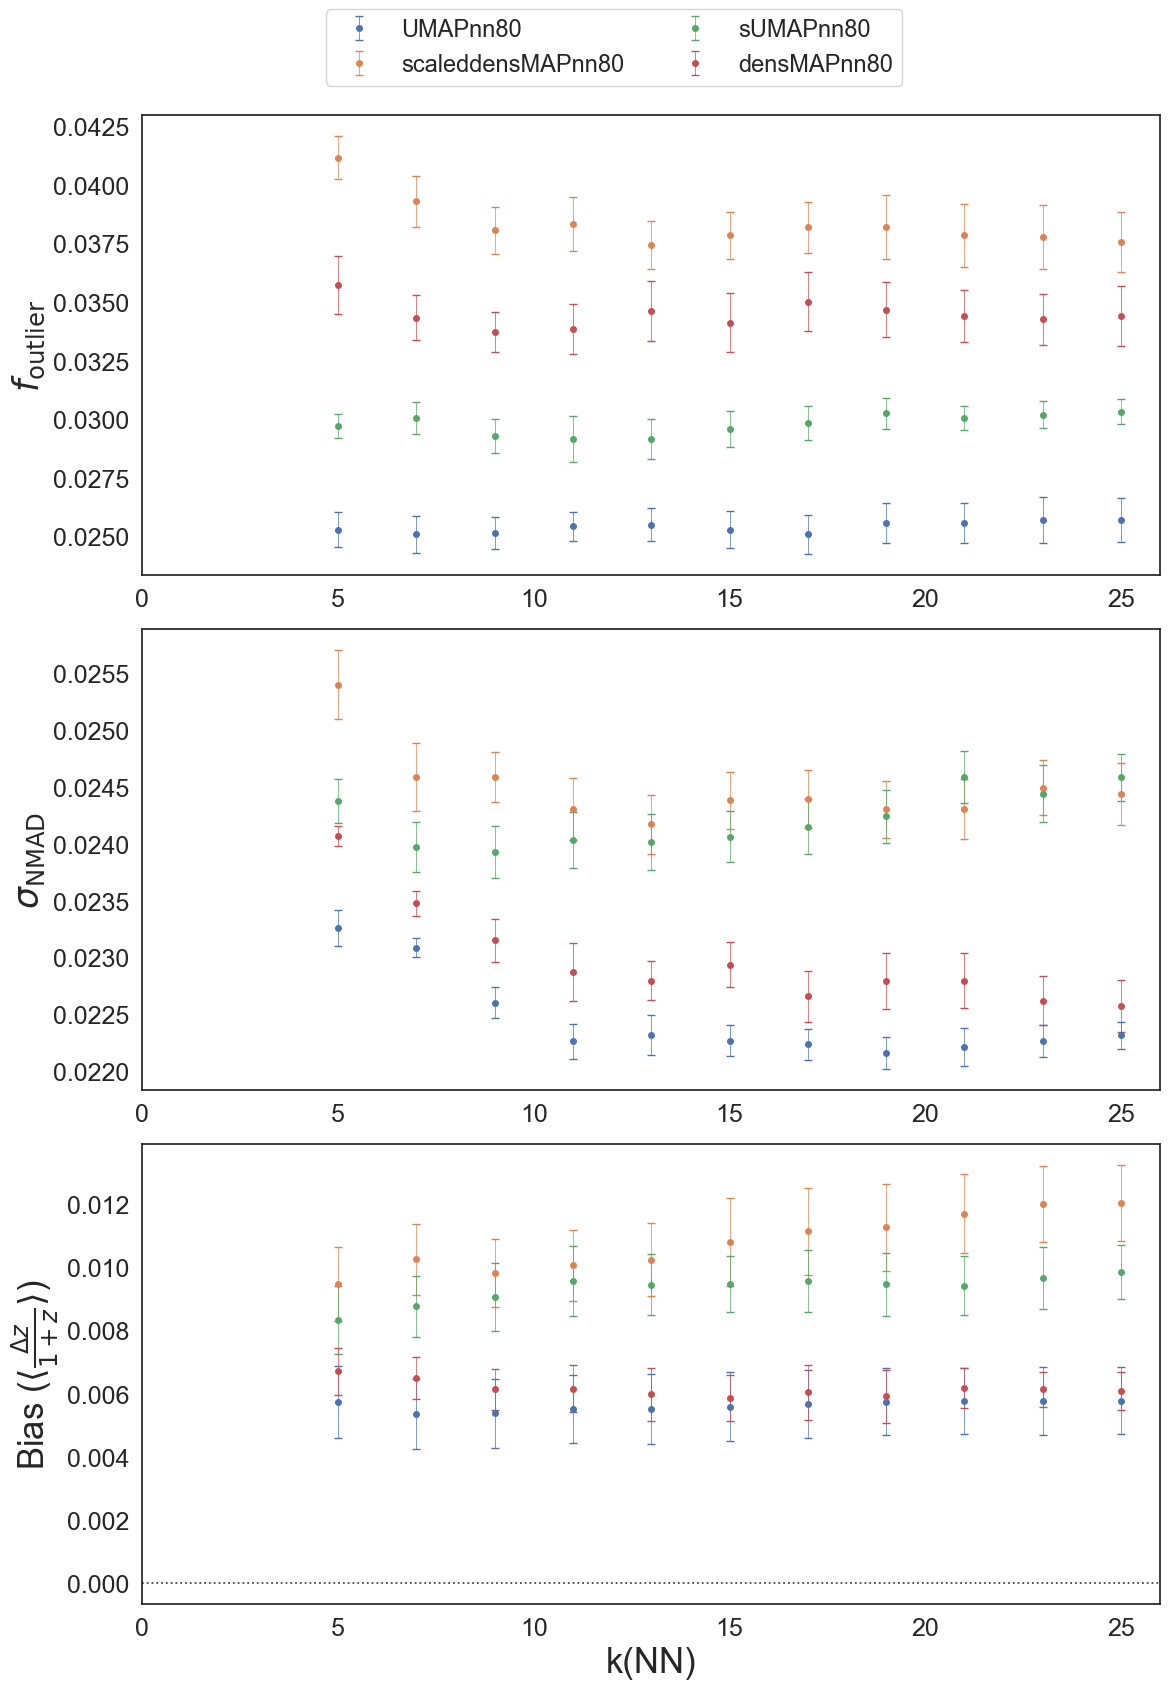

In [25]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(12,16))

    axs[0].errorbar(ks, outliers_mean, yerr=(0.5*np.asarray(outliers_std)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., label='UMAPnn80', c='C0')
    
    ylo = None
    # OUTLIERS
    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    #axs[0].set_ylim(ylo,1.05*(np.max(outliers_mean)+np.max(outliers_std)))
    axs[0].set_xlim(0,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    axs[1].errorbar(ks, nmads_mean, yerr=(0.5*np.asarray(nmads_std)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C0')

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    #axs[1].set_ylim(ylo,1.05*(np.max(nmads_mean)+np.max(nmads_std)))
    axs[1].set_xlim(0,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    axs[2].errorbar(ks, biases_mean, yerr=(0.5*np.asarray(biases_std)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C0')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    #axs[2].set_ylim(-1.05*(np.max(biases_mean)-np.max(biases_std)),1.05*(np.max(biases_mean)+np.max(biases_std)))
    axs[2].set_xlim(0,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel('k(NN)', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)

    axs[0].errorbar(ks, outliers_mean_sd, yerr=(0.5*np.asarray(outliers_std_sd)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C1', label='scaleddensMAPnn80')
    axs[1].errorbar(ks, nmads_mean_sd, yerr=(0.5*np.asarray(nmads_std_sd)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C1')
    axs[2].errorbar(ks, biases_mean_sd, yerr=(0.5*np.asarray(biases_std_sd)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C1')
    
    axs[0].errorbar(ks, outliers_mean_s, yerr=(0.5*np.asarray(outliers_std_s)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C2', label='sUMAPnn80')
    axs[1].errorbar(ks, nmads_mean_s, yerr=(0.5*np.asarray(nmads_std_s)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C2')
    axs[2].errorbar(ks, biases_mean_s, yerr=(0.5*np.asarray(biases_std_s)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C2')
    
    axs[0].errorbar(ks, outliers_mean_d, yerr=(0.5*np.asarray(outliers_std_d)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C3', label='densMAPnn80')
    axs[1].errorbar(ks, nmads_mean_d, yerr=(0.5*np.asarray(nmads_std_d)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C3')
    axs[2].errorbar(ks, biases_mean_d, yerr=(0.5*np.asarray(biases_std_d)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c='C3')

    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')
    # UMAP 

### UMAP Optimization Procedure:
1. UMAP-kNN-z k-value optimization, in a fixed UMAP embedding.

2. UMAP n_neighbors hyperparameter optimization, with fixed k-value

3. Select best values + "reasonable range" for k and n_neighbors. Pick 5 values covering each range and 
    run through testing with the other value fixed (spec-z-trained case only), (max-min)/metric as 
    uncertainty due to choice of that parameter in each redshift bin.

4. For fixed k and n_neighbors, run embeddings with 10-25 different random seeds and quantify uncertainty
    due to random seed in each redshift bin.
    
5. This covers uncertainties in UMAP-kNN-z due to embedding/optimization.
    Uncertainty due to finite test data can be calculated with 10-25 bootstrap samples of the size of the test set,
    with replacement. Measure all statistics and look at standard deviation in redshift bins.
    This is for fixed k, n_neighbors, and random seed.

### k-value optimization

First generate an embedding in which to perform k-value optimization. 

Having determined visually that embeddings with n_neighbors values between 50 and 90
are qualitatively indistinguishable, 
we can choose a value of 70 in the middle of this
range when generating this test embedding.

While the embedding is generated from all objects in the sample, only the redshift labels of objects
in the validation sample will be used in optimizing the embedding and UMAP-kNN-z parameters.

For the random_state argument, we will use 41, a value which will not be used for the final tests
or in the list of values used in quantifying uncertainty due to random seed.

In [26]:
UMAP_70_41 = umap.UMAP(n_neighbors=70, min_dist=0.0, metric='manhattan', n_components=3, random_state=41, densmap=False).fit(data[['u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-J', 'J-H']])


/Users/finianashmead/miniconda3/envs/newmac1/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [27]:
data['UMAPnn70-1'] = UMAP_70_41.embedding_[:,0].copy()
data['UMAPnn70-2'] = UMAP_70_41.embedding_[:,1].copy()
data['UMAPnn70-3'] = UMAP_70_41.embedding_[:,2].copy()

splits_70_41 = umapz2.data_split(photcat=data, speccat=spec95, valid_size=len(spec95), rs=41)
valid_70_41 = copy.deepcopy(splits_70_41['valid'])

In [28]:
valid_70_41

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,scaleddens80-1,scaleddens80-2,scaleddens80-3,dens80-1,dens80-2,dens80-3,UMAPnn80-1,UMAPnn80-2,UMAPnn80-3,UMAPnn70-1,UMAPnn70-2,UMAPnn70-3
682744,888967,149.936450,2.785401,0,0.482169,0.008109,0.021217,0.556797,0.004353,0.008433,0.649724,0.005866,0.009340,0.815287,0.006075,0.008074,1.022175,0.009601,0.010115,1.516981,0.023160,0.015645,2.479349,0.054714,0.023929,3.181551,0.075771,0.027204,3.775385,0.057224,0.016556,5.577980,0.014766,0.003503,6.055261,0.017200,0.003780,1.5429,0,NaN,27,0.99,5,1.139000e+09,0.2,0,-19.84784,-21.53190,-22.12276,10.02579,9.89337,10.08403,10.03590,1.14004,-8.917,24.692001,24.535758,24.368177,24.121724,23.876187,23.447549,22.914156,22.643403,22.457597,22.033808,21.944668,0.156243,0.167580,0.246453,0.245537,0.428638,0.533394,0.270753,6.499335,-0.409703,1.887240,0.483469,2.994827,9.795488,0.994713,3.754514,8.914530,1.925166,3.773399,9.734082
705718,915989,150.389923,1.791782,0,0.300923,0.003346,0.013912,0.391560,0.003238,0.008863,0.729946,0.004244,0.005987,0.857738,0.004264,0.005368,0.908493,0.006994,0.008269,1.053736,0.015095,0.014646,1.133205,0.028540,0.027268,1.063807,0.038095,0.040864,1.151679,0.027239,0.025818,0.553292,0.012940,0.030942,0.312715,0.016622,0.070726,0.4445,0,NaN,30,0.00,1,3.210000e+08,0.0,0,-16.35030,-17.63879,-17.70557,8.08427,8.02849,8.19774,8.06536,-1.17000,-9.212,25.203863,24.918003,24.241773,24.066614,24.004195,23.843171,23.764228,23.832843,23.746671,24.542615,25.162128,0.285860,0.676230,0.175160,0.062418,0.161025,0.078942,-0.068615,10.794587,9.170638,9.847633,0.222766,6.823456,-1.835631,0.362265,6.314400,-1.725418,1.223825,6.383770,-0.970854
132564,175014,150.121155,1.644934,0,0.281661,0.003567,0.015858,0.294709,0.003148,0.011457,0.385362,0.004180,0.011174,0.606247,0.004185,0.007456,0.866615,0.006661,0.008258,0.800703,0.015264,0.019495,0.987316,0.013438,0.014739,0.996477,0.017941,0.020548,0.986751,0.026845,0.029699,0.839995,0.013123,0.020670,0.550881,0.013868,0.033498,0.8564,0,NaN,29,0.00,7,1.015000e+09,0.1,1,-17.75778,-18.94959,-19.07940,8.71424,8.66864,8.75055,8.73949,-0.09519,-8.830,25.275684,25.226517,24.935328,24.443377,24.055434,24.141322,23.913860,23.903831,23.914481,24.089309,24.547356,0.049166,0.291189,0.491951,0.387943,-0.085888,0.227462,0.010028,10.609447,3.795608,11.286509,-1.717083,1.062936,-0.332647,-1.559213,1.493454,-0.234764,-0.776642,1.590928,0.525151
38676,53915,150.365002,2.127347,0,0.467036,0.006094,0.016220,0.526304,0.004793,0.009714,0.840886,0.006087,0.007426,1.706182,0.006378,0.004026,2.390468,0.010503,0.004710,2.376359,0.021343,0.009167,3.818460,0.042345,0.011993,4.366636,0.056518,0.014759,5.914739,0.041212,0.007602,7.887154,0.016861,0.002828,6.016602,0.020844,0.004609,0.8240,0,NaN,29,0.74,3,5.709000e+08,0.3,0,-18.17301,-20.26624,-20.98757,9.55956,9.51840,9.59472,9.53026,0.81388,-8.720,24.726624,24.596909,24.088157,23.319937,22.953793,22.960220,22.445280,22.299632,21.970161,21.657699,21.951622,0.129714,0.508752,0.768220,0.366144,-0.006427,0.514941,0.145647,8.469186,3.379476,10.668118,0.272128,1.401533,0.867776,0.472860,1.551341,1.025880,1.267917,1.582621,1.782966
739250,954912,149.888388,2.290574,0,0.826631,0.005465,0.008313,1.289190,0.00

#### perform a 5-fold cross-validation test of the validation data, recording the global metrics for different k-values

In [29]:
ks = [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
sets = {k: [0] for k in ks}
results = {k: [0] for k in ks}

outliers_mean = []
outliers_std = []
nmads_mean = []
nmads_std = []
biases_mean = []
biases_std = []

for k in ks:
    results[k], sets[k] = umapz2.crossvalidate_global(folds=5, data=valid_70_41, nn=k, map='UMAPnn70', tv='lp_photoz')
    outliers_mean.append(results[k]['outliers_mean'])
    outliers_std.append(results[k]['outliers_range'])
    nmads_mean.append(results[k]['nmads_mean'])
    nmads_std.append(results[k]['nmads_range'])
    biases_mean.append(results[k]['biases_mean'])
    biases_std.append(results[k]['biases_range'])

#### plot the results of the 5-fold cross-validation, with the means and half-ranges as the points and error bars

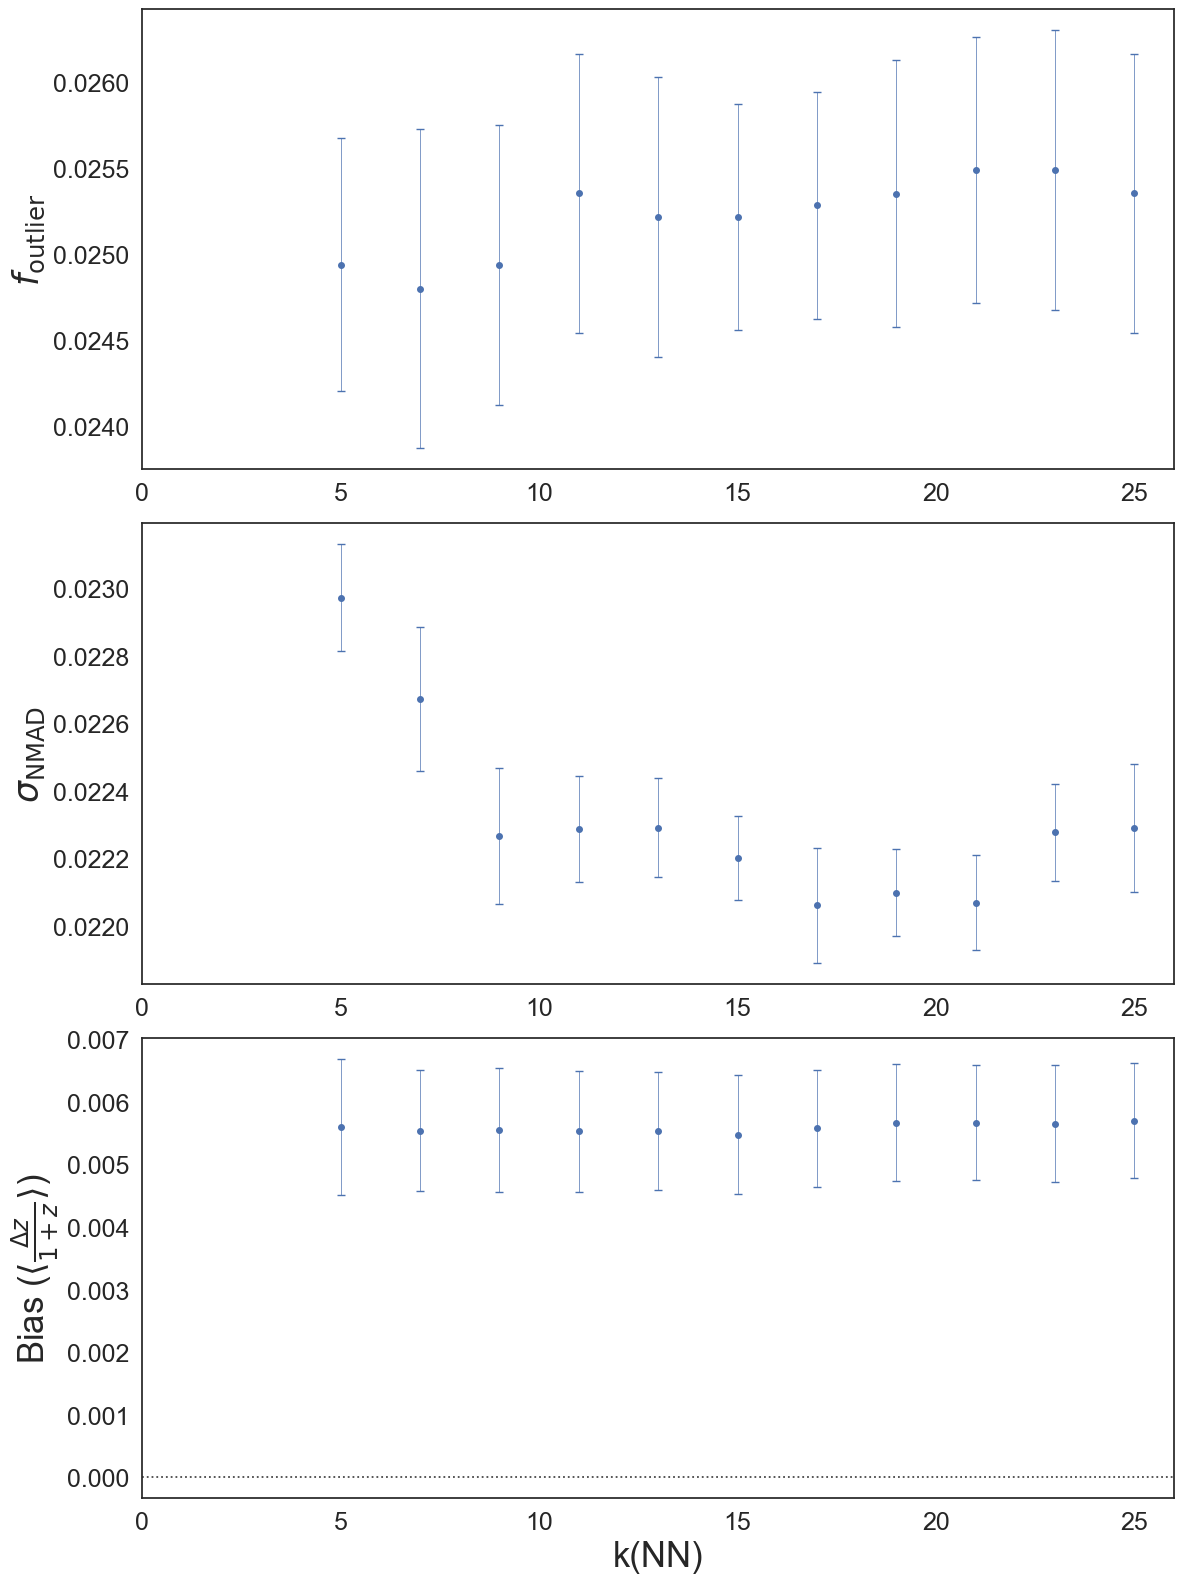

In [30]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(12,16))

    axs[0].errorbar(ks, outliers_mean, yerr=(0.5*np.asarray(outliers_std)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1.)
    
    ylo = None
    # OUTLIERS
    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    #axs[0].set_ylim(ylo,1.05*(np.max(outliers_mean)+np.max(outliers_std)))
    axs[0].set_xlim(0,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    axs[1].errorbar(ks, nmads_mean, yerr=(0.5*np.asarray(nmads_std)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1.)

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    #axs[1].set_ylim(ylo,1.05*(np.max(nmads_mean)+np.max(nmads_std)))
    axs[1].set_xlim(0,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    axs[2].errorbar(ks, biases_mean, yerr=(0.5*np.asarray(biases_std)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1.)

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    #axs[2].set_ylim(-1.05*(np.max(biases_mean)-np.max(biases_std)),1.05*(np.max(biases_mean)+np.max(biases_std)))
    axs[2].set_xlim(0,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel('k(NN)', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    #fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
    #                    ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

Based on this test, 15 is the best option for k.

### n_neighbors optimization

I have previously generated embeddings for n_neighbors values 50-90, in increments of 5. These used min_dist=0 and random_state=41. We will load the corresponding files in now.
(run_all_embeddings.ipynb contains various loops used to generate many embeddings with various hyperparameter and random seed combinations)

In [31]:
#spec_nn_maps = pd.read_parquet('umap_embeddings_spec.parquet')
data_nn = pd.read_parquet('umap_embeddings_nntest_260518.parquet')

In [32]:
spec95

,ID,specz,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H
0,535,0.82589,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848
1,670,1.16549,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038
2,692,0.30572,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,98.679499,0.078428,0.000908,133.665136,0.058089,0.000475,81.719072,0.032358,0.000524,83.615927,0.028347,0.000451,0.3269,0,NaN,29,0.29,9,5.000000e+09,0.4,1,-16.72223,-20.57175,-21.94677,10.35539,10.31772,10.39305,10.38281,0.19029,-10.190,23.602427,22.270727,21.097491,20.447285,20.039179,19.891197,19.341648,18.914433,18.584955,19.119191,19.094277,1.331700,1.173237,0.650205,0.408106,0.147982,0.549549,0.427216
3,1143,0.80030,150.589033,1.889879,0,0.063290,0.003653,0.072636,0.254108,0.004009,0.016990,1.155916,0.005216,0.004662,4.069362,0.005549,0.001476,6.650530,0.009029,0.001461,8.661979,0.019250,0.002276,14.262715,0.022103,0.001680,23.028622,0.020338,0.001009,32.456397,0.027529,0.000926,NaN,NaN,NaN,26.183528,0.044004,0.002237,0.7986,0,NaN,28,0.64,1,2.000000e+09,0.0,0,-16.79230,-21.67922,-22.74348,10.34975,10.31558,10.38392,10.32480,-6.09950,-16.440,26.896659,25.387452,23.742684,22.376184,21.842859,21.555957,21.014494,20.494330,20.121749,NaN,20.354930,1.509207,1.644768,1.366500,0.533325,0.286902,0.541463,0.520164
4,1245,1.23815,149.971382,1.711330,0,1.695707,0.006863,0.005056,1.691740,0.005530,0.003500,2.357181,0.007089,0.003094,3.366750,0.007567,0.002425,5.704886,0.012347,0.002323,6.829482,0.025867,0.003871,9.471108,0.059377,0.006786,13.002449,0.077023,0.006759,18.572509,0.051679,0.003037,29.470112,0.016731,0.000751,28.078737,0.017725,0.000840,1.2540,0,NaN,29,1.09,7,2.600000e+09,0.2,0,-20.53407,-22.57335,-23.39578,10.59188,10.55031,10.64044,10.62809,1.40000,-9.214,23.326623,23.329166,22.969017,22.581973,22.009383,21.814031,21.458998,21.114937,20.727824,20.226546,20.279056,-0.002543,0.360149,0.387045,0.572590,0.195352,0.355033,0.344061
...,...,...,

In [33]:
nn_splits = umapz2.data_split(photcat=data_nn, speccat=spec95, valid_size=len(spec95))
nn_valid = nn_splits['valid'].copy()

In [35]:
a_data = nn_valid.copy()

nn_hps = [50, 55, 60, 65, 70, 75, 80, 85, 90]

a_nn_sets = {nn_hp: [0] for nn_hp in nn_hps}
a_nn_results = {nn_hp: [0] for nn_hp in nn_hps}

a_outliers_mean = []
a_outliers_range = []
a_nmads_mean = []
a_nmads_range = []
a_biases_mean = []
a_biases_range = []

for nn_hp in nn_hps:
    a_nn_results[nn_hp], a_nn_sets[nn_hp] = umapz2.crossvalidate_global(folds=5, data=a_data, nn=15, 
                                                        map='UMAPnn'+str(nn_hp), tv='lp_photoz', dim=3,
                                                        calc='median')
    a_outliers_mean.append(a_nn_results[nn_hp]['outliers_mean'])
    a_outliers_range.append(a_nn_results[nn_hp]['outliers_range'])
    a_nmads_mean.append(a_nn_results[nn_hp]['nmads_mean'])
    a_nmads_range.append(a_nn_results[nn_hp]['nmads_range'])
    a_biases_mean.append(a_nn_results[nn_hp]['biases_mean'])
    a_biases_range.append(a_nn_results[nn_hp]['biases_range'])

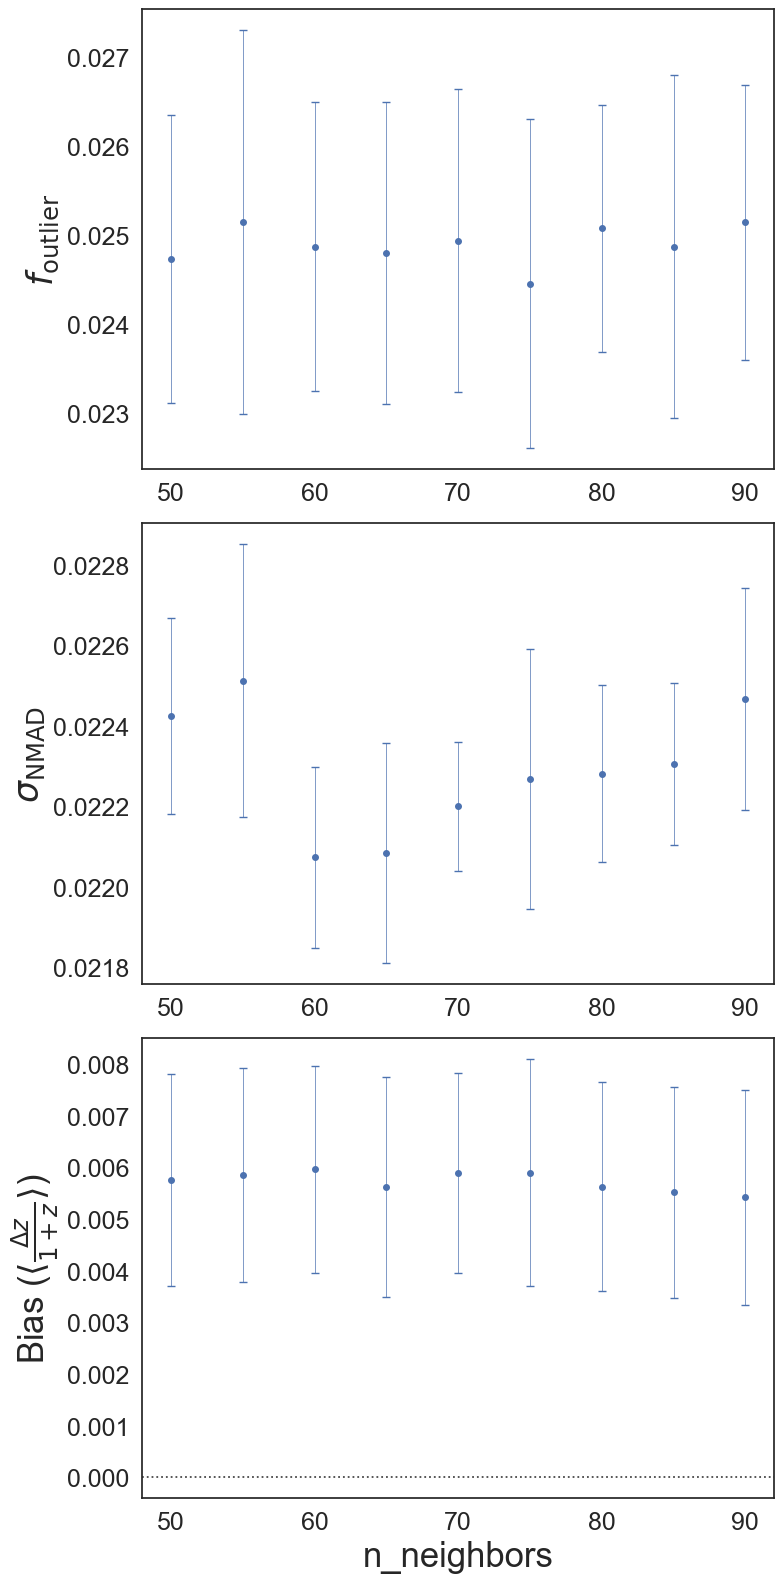

In [36]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(8,16))

    axs[0].errorbar(nn_hps, a_outliers_mean, yerr=(np.asarray(a_outliers_range)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1.)
    
    ylo = None
    # OUTLIERS
    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    #axs[0].set_ylim(ylo,1.05*(np.max(outliers_mean)+np.max(outliers_std)))
    axs[0].set_xlim(None,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    axs[1].errorbar(nn_hps, a_nmads_mean, yerr=(np.asarray(a_nmads_range)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1.)

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    #axs[1].set_ylim(ylo,1.05*(np.max(nmads_mean)+np.max(nmads_std)))
    axs[1].set_xlim(None,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    axs[2].errorbar(nn_hps, a_biases_mean, yerr=(np.asarray(a_biases_range)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1.)

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    #axs[2].set_ylim(-1.05*(np.max(biases_mean)-np.max(biases_std)),1.05*(np.max(biases_mean)+np.max(biases_std)))
    axs[2].set_xlim(None,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel('n_neighbors', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    #fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
    #                    ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')